In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.data import shepp_logan_phantom
from skimage.transform import radon, iradon
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio as psnr

In [2]:
image = shepp_logan_phantom()
image = resize(image, (256, 256), anti_aliasing=True)

In [3]:
theta = np.linspace(0., 180., 180, endpoint=False)
sinogram = radon(image, theta=theta)

In [4]:
reconstruction_fbp = iradon(
sinogram,
theta=theta,
filter_name='ramp'
)

reconstruction_psnr = psnr(image, reconstruction_fbp)
print(f"PSNR = {reconstruction_psnr:.2f} dB")

PSNR = 30.77 dB


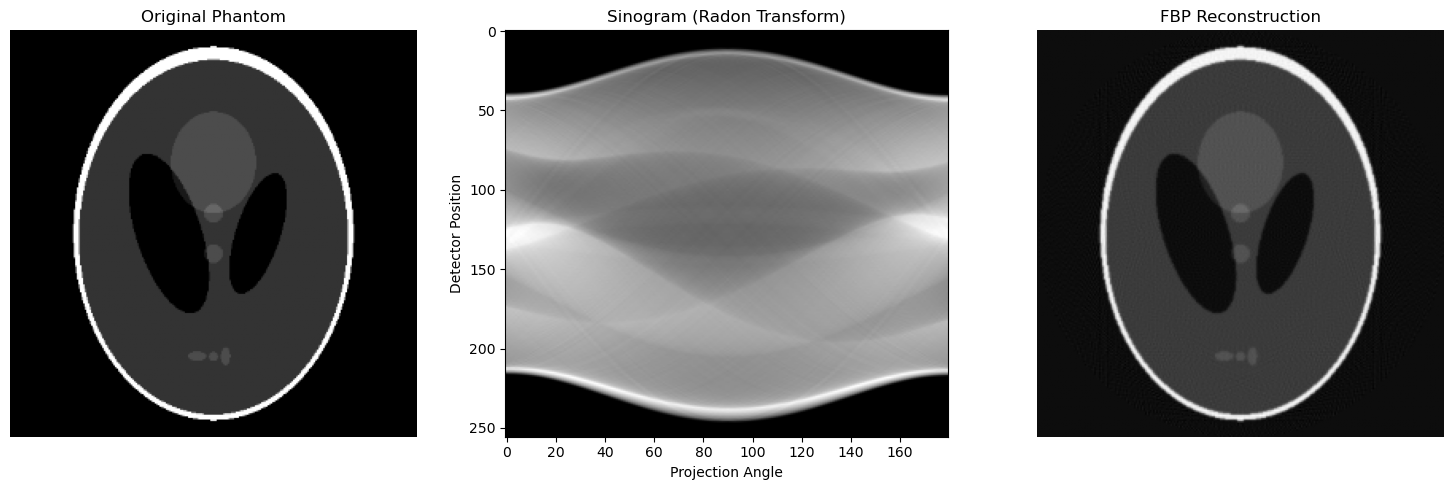

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original Phantom")
ax[0].axis('off')

ax[1].imshow(
sinogram,
cmap='gray',
aspect='auto'
)
ax[1].set_title("Sinogram (Radon Transform)")
ax[1].set_xlabel("Projection Angle")
ax[1].set_ylabel("Detector Position")

ax[2].imshow(reconstruction_fbp, cmap='gray')
ax[2].set_title("FBP Reconstruction")
ax[2].axis('off')

plt.tight_layout()
plt.show()